In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [13]:
INPUT_FILE = "dataset_denoising_gaussian.npz"

N_GRID = 64
TEST_RATIO = 0.15
VAL_RATIO = 0.15
BATCH_SIZE = 64
EPOCHS = 60
LEARNING_RATE = 1e-3
MODEL_NAME = "mlp_denoising.keras"

In [14]:
# FUNCIONES AUXILIARES

def interpolate_curve(ab2, rho, ab2_grid):
    """
    Interpolación log-log:
    rho(ab2) -> rho(ab2_grid)
    """
    x = np.log10(ab2)
    y = np.log10(rho)
    xg = np.log10(ab2_grid)
    yg = np.interp(xg, x, y)
    return 10 ** yg


def consolidate_repeated_ab2(ab2, rho):
    """
    Ordena AB/2 y promedia resistividades si hay AB/2 repetidos.
    """
    idx = np.argsort(ab2)
    ab2 = ab2[idx]
    rho = rho[idx]

    ab2_unique, inv = np.unique(ab2, return_inverse=True)

    rho_unique = np.zeros_like(ab2_unique, dtype=np.float64)
    counts = np.zeros_like(ab2_unique, dtype=np.int32)

    for i, j in enumerate(inv):
        rho_unique[j] += rho[i]
        counts[j] += 1

    rho_unique /= counts
    return ab2_unique, rho_unique


def denoise_curve(ab2_input, rho_input, model, ab2_grid, x_mean, x_std, y_mean, y_std):
    """
    Recibe curva original en AB/2 arbitrario y devuelve:
    - curva original consolidada
    - curva interpolada en la malla fija
    - curva limpia estimada en la malla fija
    - curva limpia reinterpolada a AB/2 originales
    """
    ab2_unique, rho_unique = consolidate_repeated_ab2(ab2_input, rho_input)

    rho_interp = interpolate_curve(ab2_unique, rho_unique, ab2_grid)

    x_log = np.log10(rho_interp)
    x_in = ((x_log - x_mean) / x_std).reshape(1, -1)

    y_pred_n = model.predict(x_in, verbose=0)[0]
    y_pred_log = y_pred_n * y_std + y_mean
    rho_clean_grid = 10 ** y_pred_log

    rho_clean_original = interpolate_curve(ab2_grid, rho_clean_grid, ab2_unique)

    return ab2_unique, rho_unique, rho_interp, rho_clean_grid, rho_clean_original

In [15]:
# CARGAR DATASET

data = np.load(INPUT_FILE)

clean_curves = data["clean_curves"]
noisy_curves = data["noisy_curves"]
ab2_all = data["ab2"]
n_ab2_all = data["n_ab2"]

print("clean_curves:", clean_curves.shape)
print("noisy_curves:", noisy_curves.shape)
print("ab2_all     :", ab2_all.shape)
print("n_ab2_all   :", n_ab2_all.shape)

clean_curves: (40000, 40)
noisy_curves: (40000, 40)
ab2_all     : (40000, 40)
n_ab2_all   : (40000,)


In [16]:
# CONSTRUIR MALLA FIJA GLOBAL

all_ab2_valid = []
for i in range(len(n_ab2_all)):
    npts = n_ab2_all[i]
    all_ab2_valid.append(ab2_all[i, :npts])

all_ab2_valid = np.concatenate(all_ab2_valid)

ab2_min = np.min(all_ab2_valid)
ab2_max = np.max(all_ab2_valid)

ab2_grid = np.logspace(np.log10(ab2_min), np.log10(ab2_max), N_GRID)

print("ab2_min :", ab2_min)
print("ab2_max :", ab2_max)
print("ab2_grid shape:", ab2_grid.shape)

ab2_min : 1.0000197
ab2_max : 398.04373
ab2_grid shape: (64,)


In [17]:
# INTERPOLAR TODAS LAS CURVAS EN LA MALLA FIJA

X = np.zeros((len(n_ab2_all), N_GRID), dtype=np.float32)  # curvas con ruido
Y = np.zeros((len(n_ab2_all), N_GRID), dtype=np.float32)  # curvas limpias

for i in range(len(n_ab2_all)):
    npts = n_ab2_all[i]

    ab2_i = ab2_all[i, :npts]
    noisy_i = noisy_curves[i, :npts]
    clean_i = clean_curves[i, :npts]

    X[i] = interpolate_curve(ab2_i, noisy_i, ab2_grid)
    Y[i] = interpolate_curve(ab2_i, clean_i, ab2_grid)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (40000, 64)
Y shape: (40000, 64)


In [18]:
# PASAR A LOG10

X_log = np.log10(X)
Y_log = np.log10(Y)

In [19]:
# DIVIDIR TRAIN, VAL Y TEST

N = len(X_log)
idx = np.random.permutation(N)

n_test = int(TEST_RATIO * N)
n_val = int(VAL_RATIO * N)

test_idx = idx[:n_test]
val_idx = idx[n_test:n_test + n_val]
train_idx = idx[n_test + n_val:]

X_train, Y_train = X_log[train_idx], Y_log[train_idx]
X_val, Y_val = X_log[val_idx], Y_log[val_idx]
X_test, Y_test = X_log[test_idx], Y_log[test_idx]

print("Train:", X_train.shape, Y_train.shape)
print("Val  :", X_val.shape, Y_val.shape)
print("Test :", X_test.shape, Y_test.shape)

Train: (28000, 64) (28000, 64)
Val  : (6000, 64) (6000, 64)
Test : (6000, 64) (6000, 64)


In [20]:
# NORMALIZACIÓN

x_mean = X_train.mean(axis=0)
x_std = X_train.std(axis=0) + 1e-8

y_mean = Y_train.mean(axis=0)
y_std = Y_train.std(axis=0) + 1e-8

X_train_n = (X_train - x_mean) / x_std
X_val_n   = (X_val   - x_mean) / x_std
X_test_n  = (X_test  - x_mean) / x_std

Y_train_n = (Y_train - y_mean) / y_std
Y_val_n   = (Y_val   - y_mean) / y_std
Y_test_n  = (Y_test  - y_mean) / y_std

In [21]:
# CREAR MLP

model = models.Sequential([
    layers.Input(shape=(N_GRID,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(N_GRID, activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,096 (547.25 KB)

 Trainable params: 140,096 (547.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# ENTRENAR

cb = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6
    )
]

history = model.fit(
    X_train_n, Y_train_n,
    validation_data=(X_val_n, Y_val_n),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=cb
)

Epoch 1/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0327 - mae: 0.0821 - val_loss: 0.0024 - val_mae: 0.0341 - learning_rate: 0.0010
Epoch 2/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0021 - mae: 0.0328 - val_loss: 0.0023 - val_mae: 0.0336 - learning_rate: 0.0010
Epoch 3/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018 - mae: 0.0309 - val_loss: 0.0016 - val_mae: 0.0291 - learning_rate: 0.0010
Epoch 4/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0017 - mae: 0.0293 - val_loss: 0.0014 - val_mae: 0.0260 - learning_rate: 0.0010
Epoch 5/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0016 - mae: 0.0290 - val_loss: 0.0016 - val_mae: 0.0292 - learning_rate: 0.0010
Epoch 6/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014 - mae: 0.0272 - val_loss: 0.0016 - val_mae: 0.0297 - learning_rate: 0.0010
Epoch 7/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - mae: 0.0277 - val_loss: 0.0014 - val_mae: 0.0262 - learning_rate: 0.0010
Epoch 

In [23]:
# GUARDAR MODELO Y PARAMETROS

model.save(MODEL_NAME)

np.savez_compressed(
    "mlp_denoising_norm.npz",
    ab2_grid=ab2_grid,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std
)

print(f"Modelo guardado en: {MODEL_NAME}")
print("Normalización guardada en: mlp_denoising_norm.npz")

Modelo guardado en: mlp_denoising.keras
Normalización guardada en: mlp_denoising_norm.npz


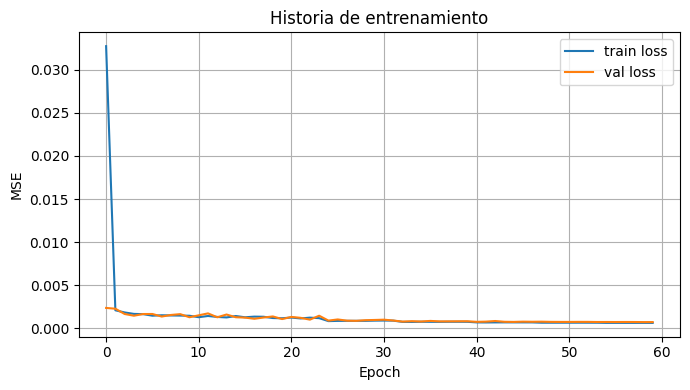

In [24]:
# HISTORIAL DE ENTRENAMIENTO

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Historia de entrenamiento")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

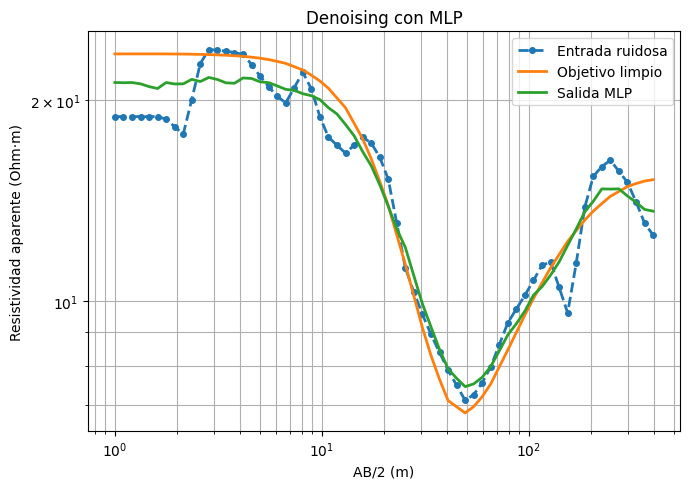

In [30]:
# EJEMPLO CON CURVAS DEL TEST

Y_pred_n = model.predict(X_test_n, verbose=0)
Y_pred_log = Y_pred_n * y_std + y_mean

X_test_log = X_test_n * x_std + x_mean
Y_test_log = Y_test_n * y_std + y_mean

X_test_curve = 10 ** X_test_log
Y_test_curve = 10 ** Y_test_log
Y_pred_curve = 10 ** Y_pred_log

j = np.random.randint(0, len(X_test_curve))

plt.figure(figsize=(7, 5))
plt.loglog(ab2_grid, X_test_curve[j], 'o--', label='Entrada ruidosa', linewidth=2, markersize=4)
plt.loglog(ab2_grid, Y_test_curve[j], '-', label='Objetivo limpio', linewidth=2)
plt.loglog(ab2_grid, Y_pred_curve[j], '-', label='Salida MLP', linewidth=2)
plt.xlabel("AB/2 (m)")
plt.ylabel("Resistividad aparente (Ohm·m)")
plt.title("Denoising con MLP")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# LIMPIAR DATOS REALES

res_app = np.array([
    43.025, 65.821, 91.297, 102.94, 108.34, 116.88, 105.47, 73.699,
    86.071, 68.7361, 62.221, 68.475, 72.662, 77.574, 72.827, 74.94,
    81.644, 76.599, 76.703, 83.44, 69.359
], dtype=np.float64)

ab2 = np.array([
    2, 4, 8, 10, 10, 20, 25, 35, 40, 40, 45, 50, 55, 55, 60, 75,
    80, 80, 85, 90, 95
], dtype=np.float64)

ab2_original, rho_original, rho_input_grid, rho_clean_grid, rho_clean_original = denoise_curve(
    ab2_input=ab2,
    rho_input=res_app,
    model=model,
    ab2_grid=ab2_grid,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std
)

print("AB/2 originales para inversión:")
print(ab2_original)

print("\nCurva original consolidada:")
print(rho_original)

print("\nCurva limpia estimada en AB/2 originales:")
print(rho_clean_original)

AB/2 originales para inversión:
[ 2.  4.  8. 10. 20. 25. 35. 40. 45. 50. 55. 60. 75. 80. 85. 90. 95.]

Curva original consolidada:
[ 43.025    65.821    91.297   105.64    116.88    105.47     73.699
  77.40355  62.221    68.475    75.118    72.827    74.94     79.1215
  76.703    83.44     69.359  ]

Curva limpia estimada en AB/2 originales:
[ 45.29679247  63.59304638  94.79746974 104.67663662 109.39565053
 101.71115217  85.85035744  79.22015538  74.62650004  72.14240184
  71.40757179  71.47284755  72.01039461  72.20360982  72.63023575
  72.21014314  71.27772822]


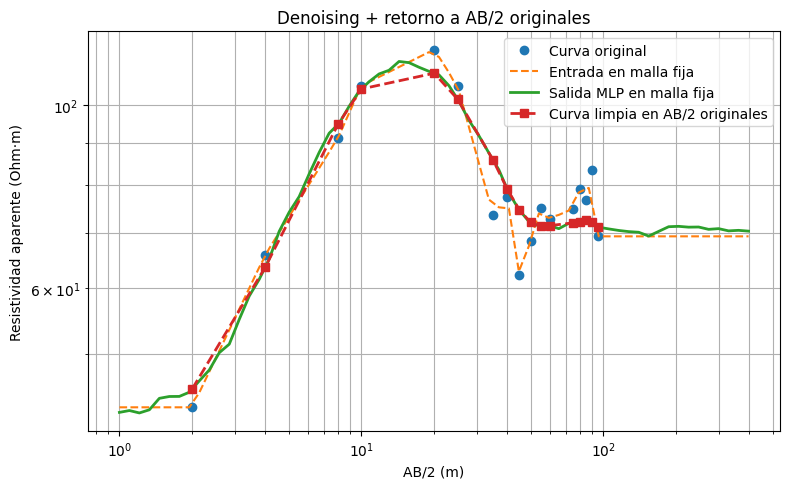

In [27]:
plt.figure(figsize=(8, 5))
plt.loglog(ab2_original, rho_original, 'o', label='Curva original')
plt.loglog(ab2_grid, rho_input_grid, '--', label='Entrada en malla fija')
plt.loglog(ab2_grid, rho_clean_grid, '-', linewidth=2, label='Salida MLP en malla fija')
plt.loglog(ab2_original, rho_clean_original, 's--', linewidth=2, label='Curva limpia en AB/2 originales')
plt.xlabel("AB/2 (m)")
plt.ylabel("Resistividad aparente (Ohm·m)")
plt.title("Denoising + retorno a AB/2 originales")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
ab2_inv = ab2_original
rho_inv = rho_clean_original

print("AB/2 para inversión:")
print(ab2_inv)

print("\nCurva denoised para inversión:")
print(rho_inv)

AB/2 para inversión:
[ 2.  4.  8. 10. 20. 25. 35. 40. 45. 50. 55. 60. 75. 80. 85. 90. 95.]

Curva denoised para inversión:
[ 45.29679247  63.59304638  94.79746974 104.67663662 109.39565053
 101.71115217  85.85035744  79.22015538  74.62650004  72.14240184
  71.40757179  71.47284755  72.01039461  72.20360982  72.63023575
  72.21014314  71.27772822]
